In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import SysSimX

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from MyModels.MasterPendulum.pendulum_ode import PendulumODE, ramp_torque
from fem_pendulum import FEMPendulum
import pendulum_config as config

-------------------------------

**Instantiate and Configure FEM Pendulum**

In [2]:
model = FEMPendulum(name="FEM_Pendulum", group="Plant")

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 0
init_params.drive_torque = 40.0  # Nm

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1.0
sim_params.with_contact = False
sim_params.use_gravity = False

anim_params = config.AnimationParameters()
anim_params.animate = False

model.set_parameters(init_params=init_params,
                     sim_params=sim_params,
                     anim_params=anim_params)

model.initialize(0.0)
model.setup_monitoring()
model.display_monitoring()
model.initialize_scene()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [5]:
t_end = model.sim_params.t_end
dt = model.sim_params.tau
t = 0.0

# Analytical Solution using ODE Pendulum
pendulum_ode = PendulumODE(mass=model.mass,
                           length=model._equivalent_length,
                           inertia=model.inertia,
                           g= 9.81 if model.sim_params.use_gravity else 0.0)

torque_amp = init_params.drive_torque
t_an_vals, q_an_vals, omega_an_vals, alpha_an_vals = pendulum_ode.solve(t_span=(0.0, t_end),
                                                    y0=[np.deg2rad(init_params.angular_position_deg), 0.0],
                                                    torque_func=ramp_torque(sim_params.t_end, torque_amp),
                                                    dt=dt)

In [6]:
torque_func: callable = ramp_torque(t_end, torque_amp)

while t < t_end:
    # 1) Compute input torque
    torque = torque_func(t)
    
    # 2) Perform simulation step
    model.set_inputs({'torque': torque}, t=t)

    # 3) Integrate one time step
    model.do_step(t, dt)

    # 4) Advance time
    t += dt

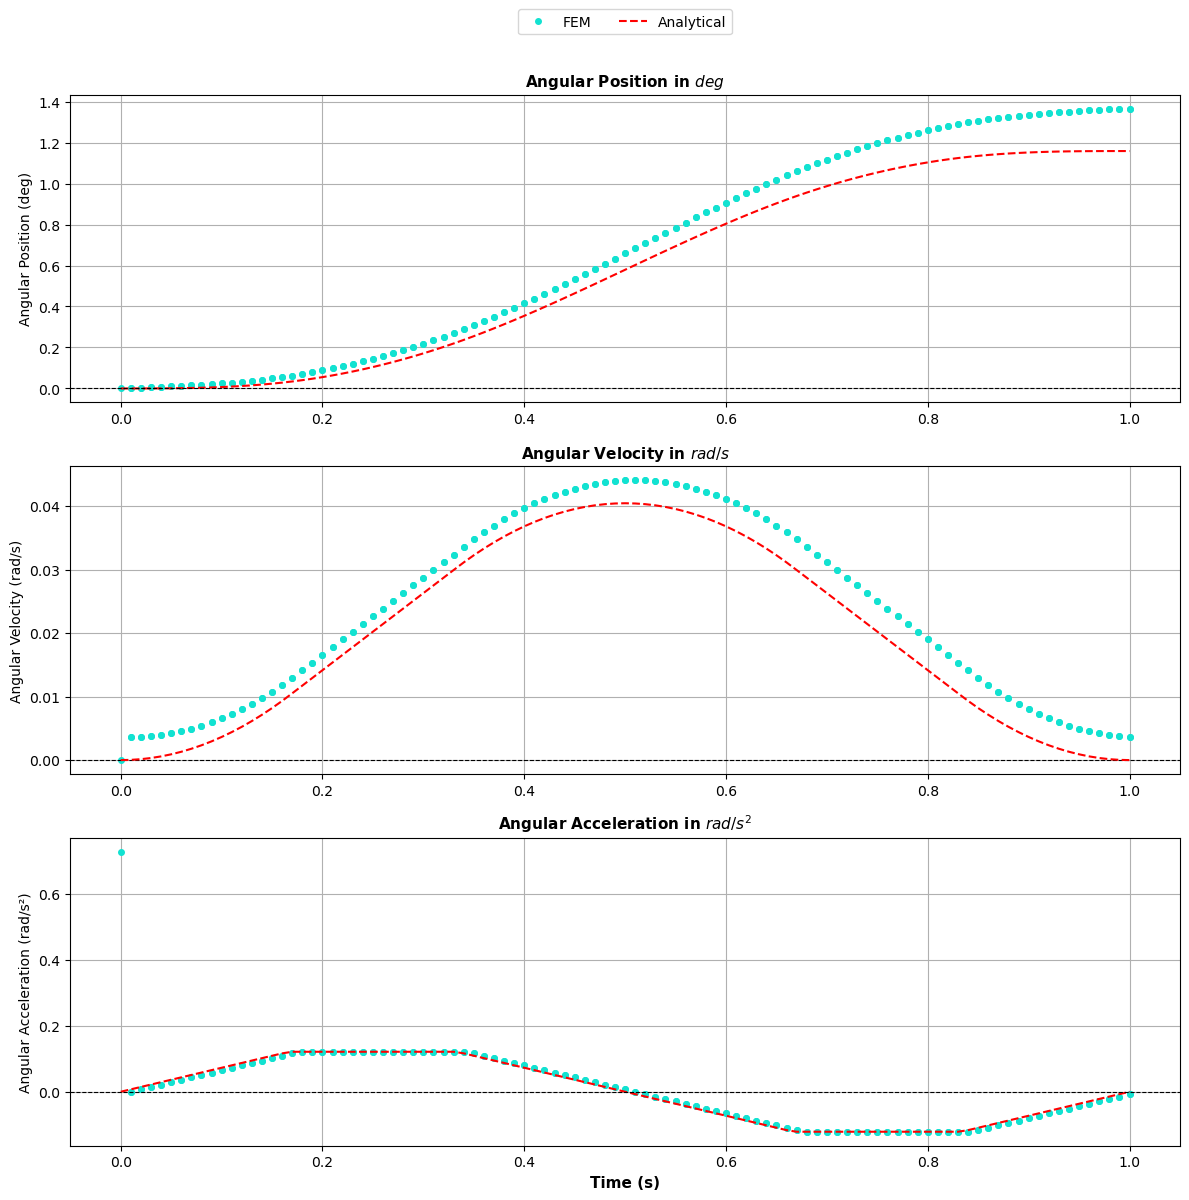

In [8]:
t_vals, q_fem_vals = zip(*model.outputs['q'].history)
q_fem_vals = [val.magnitude for val in q_fem_vals]
t_vals, omega_fem_vals = zip(*model.outputs['omega'].history)
omega_fem_vals = [val.magnitude for val in omega_fem_vals]
t_vals, alpha_fem_vals = zip(*model.outputs['alpha'].history)
alpha_fem_vals = [val.magnitude for val in alpha_fem_vals]

marker_size = 4
fem_style = {'color': "#12e2d1", 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size, 'linewidth': 3.5}  
opensim_style = {'color': "#f8c20f", 'linestyle': 'None', 'marker': 's', 'markersize': marker_size, 'linewidth': 3.5} 
eqb_style = {'color': "#1d8d43", 'linestyle': 'None', 'marker': '^', 'markersize': marker_size, 'linewidth': 3.5}
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

plt.figure(figsize=(12, 12))

plt.subplot(3,1,1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals, np.rad2deg(q_fem_vals), label="FEM", **fem_style)
plt.plot(t_an_vals, np.rad2deg(q_an_vals), label="Analytical", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Position (deg)")
plt.grid(which='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)

plt.subplot(3,1,2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals, omega_fem_vals, label="FEM", **fem_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.plot(t_an_vals, omega_an_vals, label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(which='both')

plt.subplot(3,1,3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals, alpha_fem_vals, label="FEM", **fem_style)
plt.plot(t_an_vals, alpha_an_vals, label="Analytical", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which='both')

plt.xlabel("Time (s)", **fontdict)
plt.tight_layout()
#plt.savefig("../figures/StateSynchronization_driven.svg")
plt.show()

---------------------